<a href="https://colab.research.google.com/github/ShmaliukhDA/MD_10_Home_tasks/blob/main/%22HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



In [23]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Аналітика Даних/Модуль 11/Data_csv/yulu_rental.csv')

In [4]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [5]:
seasony_map = {
    12: 'Q1 (Winter)', 1:'Q1 (Winter)', 2:'Q1 (Winter)',
    3:'Q2 (Summer)', 4:'Q2 (Summer)', 5:'Q2 (Summer)',
    6:'Q3 (Monsoon)', 7:'Q3 (Monsoon)', 8:'Q3 (Monsoon)', 9:'Q3 (Monsoon)',
    10:'Q4 (Post-Monsoon)', 11:'Q4 (Post-Monsoon)'
}

df['season_India'] = df['month'].map(seasony_map)

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [6]:
unique_week_day=df['weekday_num'].unique()
unique_week_day

array([5, 6, 0, 1, 2, 3, 4], dtype=int32)

In [7]:
# Рівень деталізації даного датасету це 1 рядок = 1 годині


print(df.shape)
print(df.size)

(10886, 20)
217720


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


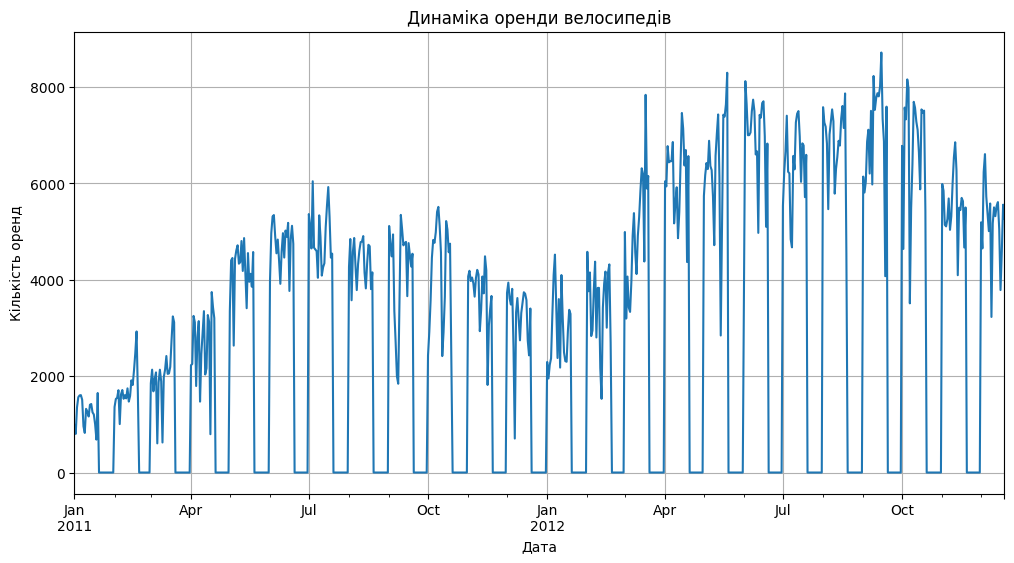

In [8]:
daily_count=df['count'].resample('D').sum()
daily_count.plot(
    figsize = (12,6),
    title = 'Динаміка оренди велосипедів'
    )
plt.xlabel('Дата')
plt.ylabel('Кількість оренд')
plt.grid(True)

plt.show()

In [9]:
unique_day=df['day'].unique()
unique_day

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19], dtype=int32)

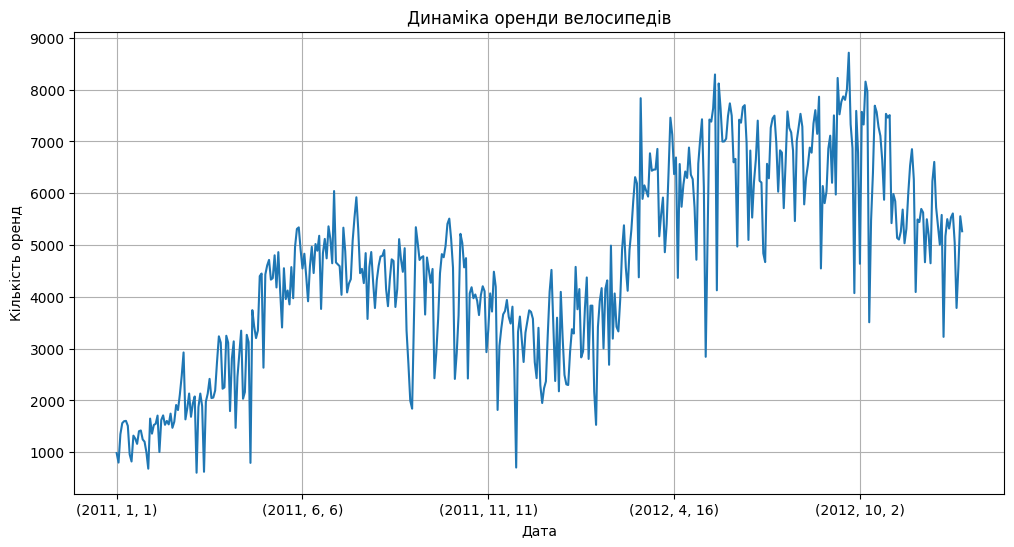

In [10]:
#Графік з вилученими днями без даних

daily_count=df.groupby(['year', 'month', 'day'])['count'].sum()
daily_count.plot(
    figsize = (12,6),
    title = 'Динаміка оренди велосипедів'
    )
plt.xlabel('Дата')
plt.ylabel('Кількість оренд')
plt.grid(True)

plt.show()



**1. Чому графік має заломи (падіння до нуля) та як їх прибрати?**

* **Причина:** Заломи спричинені специфікою вибірки (Train/Test split) — у датасеті відсутні записи з 20-го числа і до кінця кожного місяця. При використанні `.resample()` ці пропущені дні автоматично заповнюються нулями, що й створює періодичні провали.
* **Усунення:** Замість `.resample()` застосовано метод `.groupby()`. Він працює виключно з фактично наявними днями (з 1-го по 19-те число), що дозволило прибрати штучні нулі й отримати безперервний лінійний графік.

**2. Загальні тенденції на графіку**

* Дані охоплюють дворічний період і демонструють виражений загальний тренд до зростання.
* Виразно спостерігаються сезонні коливання: періодичні підйоми та спади оренди залежно від пори року, що потребує окремого аналітичного підтвердження.

**3. Наявність та причини аномалій (піків і провалів)**

* **Наявність:** На графіку присутні локальні аномально високі (піки) та низькі (обвали) значення навіть у межах одного місяця.
* **Можливі причини:** Окрім сезонності, такі коливання зазвичай зумовлені зовнішніми факторами — резкими змінами погодних умов (дощ, похолодання/спека), вихідними або святковими днями, а також технічними збоями у системі оренди.

**Додаткова інформація:**

* **Первинний графік:** Відображає суттєві заломи (падання в нуль), що викликано специфікою часового ряду.
* **Перевірка даних:** Аналіз унікальних днів у місяці підтвердив гіпотезу про відсутність записів з 20-го числа до кінця кожного місяця.
* **Оновлений графік:** Побудований за допомогою `.groupby()`, що дозволило врахувати лише наявні дні та отримати безперервну динаміку.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

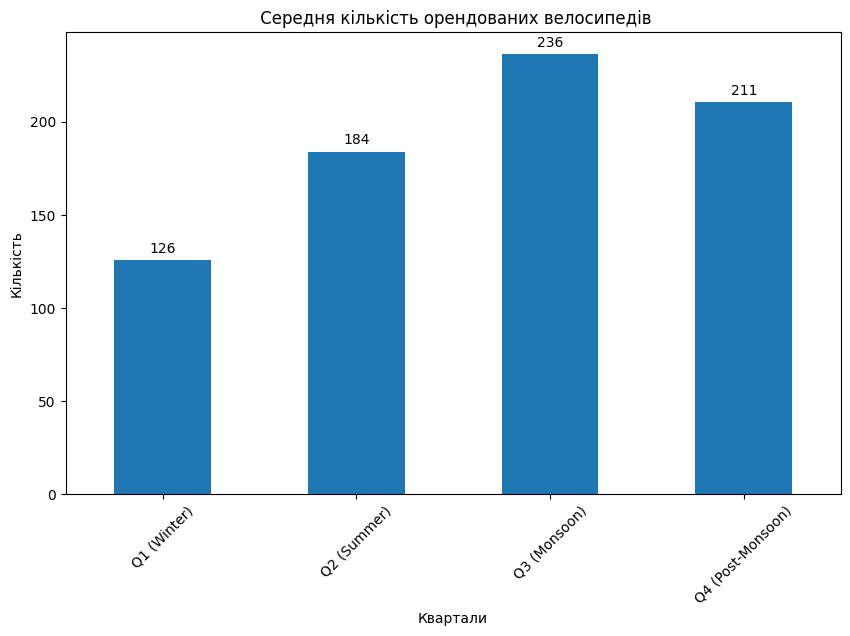

In [11]:
q_mean=df.groupby('season_India')['count'].mean()
ax = q_mean.plot.bar(
    figsize = (10,6),
    title = ' Cередня кількість орендованих велосипедів',
    xlabel='Квартали',
    ylabel='Кількість',
    legend=False
    )
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.xticks(rotation=45)
plt.show()

In [12]:

q1_sum = df[df['season_India'] == 'Q1 (Winter)']['count'].mean()

print(f"Середнє значення за перший квартал: {q1_sum:,.0f}")

q3_sum =df[df['season_India'] == 'Q3 (Monsoon)']['count'].mean()
print(f"Середнє значення за третій квартал: {q3_sum:,.0f}")

gap = q3_sum/q1_sum
print(f"Різниця між найбільши і найменшим кварталом: {gap:,.2f} рази.")

Середнє значення за перший квартал: 126
Середнє значення за третій квартал: 236
Різниця між найбільши і найменшим кварталом: 1.88 рази.




**1. В який квартал спостерігається найбільша середня кількість оренди?**

* Найбільша середня активність припадає на **3-й бізнес-квартал (Monsoon / літні місяці)**. Аналіз виконано на основі кастомної місцевої сезонності (4 місяці літа).

**2. Пояснення сезонної закономірності**

* Сплеск попиту в 3-му кварталі зумовлений сприятливими погодними умовами літнього періоду. Відсутність опадів та тепла погода роблять велопоїздки максимально популярними серед користувачів.

**3. Різниця між найпопулярнішим та найменш популярними кварталами**

* **Максимальний попит:** 3-й квартал (Літо / Monsoon).
* **Мінімальний попит:** 1-й квартал (Зима).
* **Співвідношення:** У зимовий період (1-й квартал) середня кількість оренд **у 1.88 раза менша**, ніж у піковий літній період (3-й квартал), що пояснюється сезонним погіршенням погодних умов.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


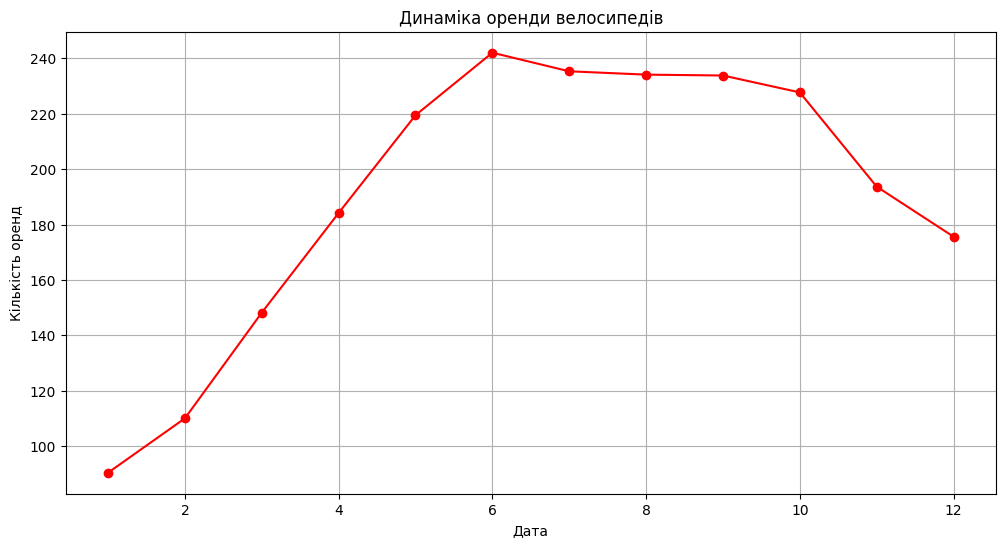

In [13]:
hour_count=df.groupby(['month'])['count'].mean()
hour_count.plot(
    figsize=(12,6),
    title='Динаміка оренди велосипедів',
    marker='o',
    color='red'
    )
plt.xlabel('Дата')
plt.ylabel('Кількість оренд')
plt.grid(True)

plt.show()

1. Пік оренди велосипедів припадає на 6 місяць і дана кількість тримається до 10 місяця, після ми спостерігаємо спад.
2. Так закономірність зберігається.
3. Клімат суттєво впливає на оренду велосипедів протягом року, у літній період більш поширений спосіб пересування і активного відпочинку порівняно із зимою чи осінню.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

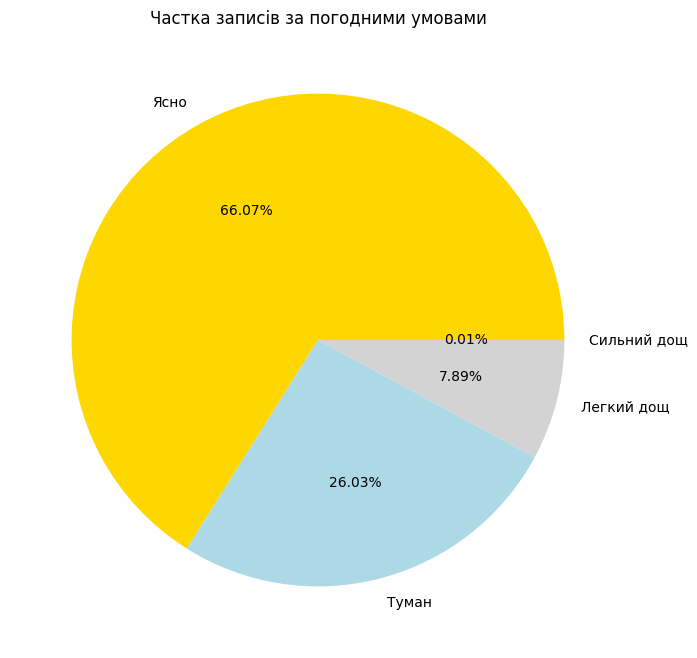

In [14]:
weather_chart = df['weather'].value_counts()
weather_chart

,count
weather,
1,7192
2,2834
3,859
4,1


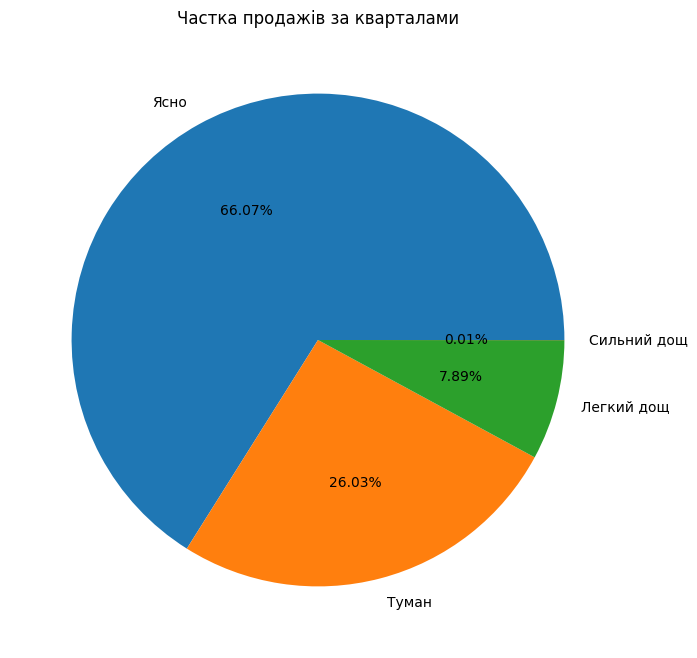

In [15]:
weather_chart.plot.pie(
     figsize=(8,8),
    autopct='%1.2f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title='Частка продажів за кварталами',
    ylabel=''
)
plt.show()



**1. Яка погода переважає в датасеті?**

* Переважну більшість часу в датасеті спостерігається **ясна погода (Clear)**, яка складає **66.07%** від усіх записів.

**2. Чи є дні із сильним дощем і яка їх частка?**

* Так, дні із сильним дощем присутні в датасеті, проте їхня частка є критично малою і становить лише **0.01%**.

**3. Вплив погодних умов на попит на оренду велосипедів**

* **Ясна погода та легкий туман:** Попит залишається стабільним та високим (за умови помірної інтенсивності туману).
* **Опади (дощ / сніг):** Навіть легкі опади призводять до зниження попиту, тоді як сильний дощ спричиняє майже повне падіння активності оренди.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

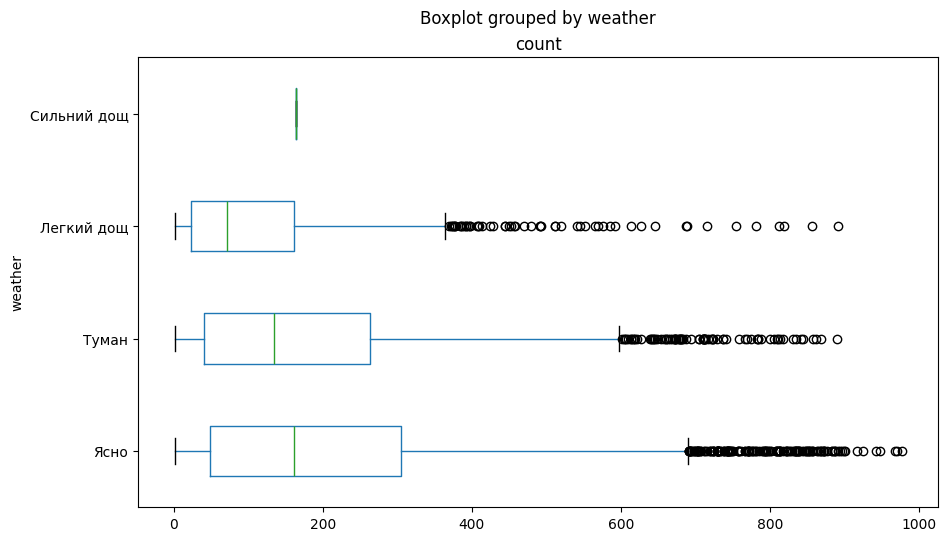

In [16]:
df.boxplot(
    column='count',
    by='weather',
    figsize=(10,6),
    grid=False,
    vert=False
)
plt.yticks([1, 2, 3, 4],['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.show()



1. **Найбільший розкид у кількості оренди:** При погоді **Ясно**. У цієї категорії найширший "прямокутник" та найдовші "вуса" (за винятком викидів) — від 0 майже до 700.
2. **Наявність викидів :** Так, викиди є. Вони присутні при погоді **Ясно**, **Туман** та **Легкий дощ** (на графіку це окремі кружечки праворуч від вусів). При погоді **Сильний дощ** викидів немає (там загалом лише одне або кілька поодиноких спостережень).
3. **Найвище медіанне значення:** При погоді **Ясно** (приблизно на рівні ~160, тоді як у категорії Туман вона трохи лівіше ~135, у Легкий дощ ~70, а у Сильний дощ ~164, але категорія Ясно має значно ширший і вищий загальний розподіл).

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

In [17]:
df['season_india_code'] = df['season_India'].astype('category').cat.codes

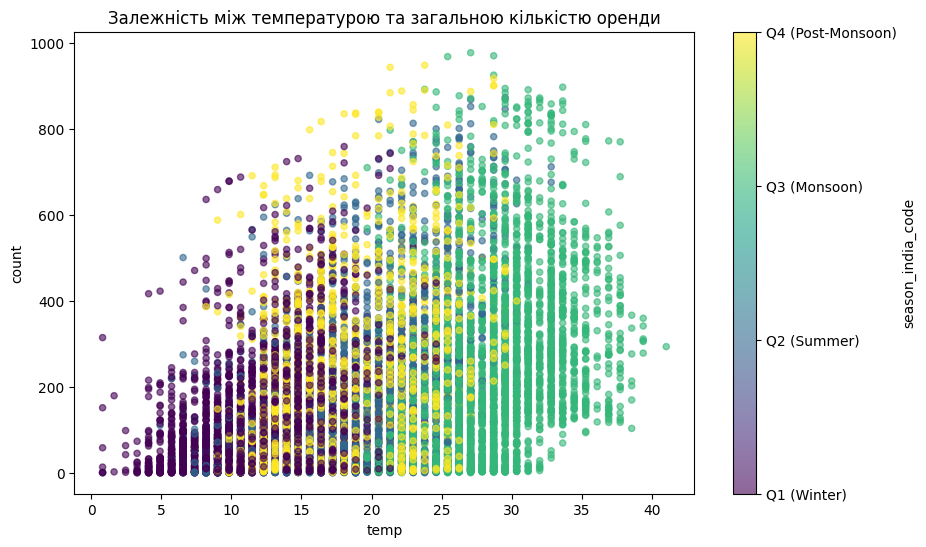

In [18]:
ax = df.plot.scatter(
x='temp',
y='count',
c='season_india_code',
colormap='viridis',
title='Залежність між температурою та загальною кількістю оренди',
figsize=(10,6),
alpha=0.6
)
unique_labels = df['season_India'].astype('category').cat.categories
colorbar = ax.collections[0].colorbar
colorbar.set_ticks(range(len(unique_labels)))
colorbar.set_ticklabels(unique_labels)
plt.show()


Кореляціця між температурою та кількістю оренди

 Можна зробити висновок що при нижчих температурах (від 0 до 15 °С) кількість орендованих велосипедів є нижчою, тоді як при помірній  та більш високій температурі ( від 15 до 35 °С) кількісь оренди уртимується на найбільшому рівні.
 Також можемо спостерігати що при екстремально високій температурі (від 35 до 40 °С) попит на оренду скорочується.

 Тому залежність між температурою навколишнього середовища та кількістю орендованих велосипедів існує.


## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [19]:
df['weekday'] = df['weekday'].replace({'nan': 'Wednesday'}).fillna('Wednesday')

In [20]:
ordered_days = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]
df['weekday'] = pd.Categorical(
    df['weekday'], categories=ordered_days, ordered=True
)

/tmp/ipykernel_4484/3910680360.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekday_mean=df.groupby('weekday')[['casual', 'registered']].mean()


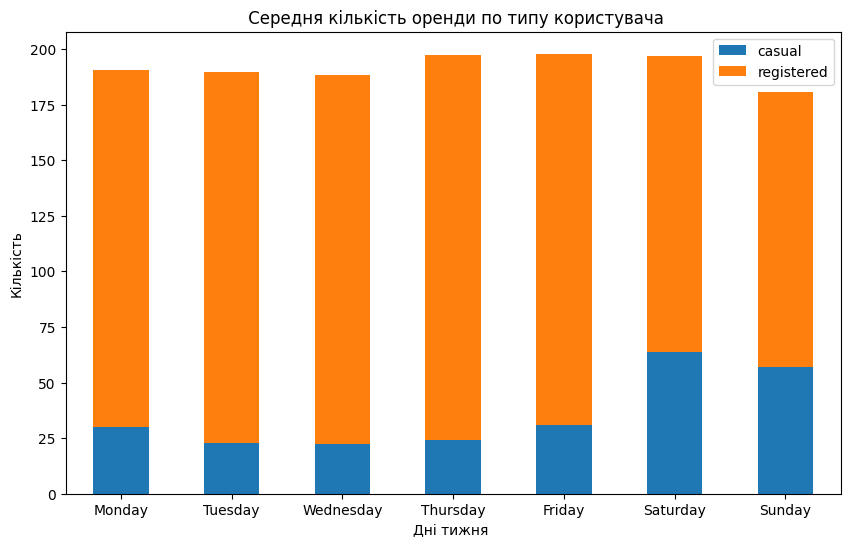

In [21]:
weekday_mean=df.groupby('weekday')[['casual', 'registered']].mean()
weekday_mean.plot(
    kind='bar',
    figsize = (10,6),
    title = ' Cередня кількість оренди по типу користувача',
    xlabel='Дні тижня ',
    ylabel='Кількість',
    stacked=True)
plt.xticks(rotation=0)
plt.show()



**1. Дні з найбільшою кількістю оренди від зареєстрованих користувачів (`registered`):**

* Найвищий рівень оренди спостерігається у **вівторок, середу та четвер** — усі три дні знаходяться приблизно на одному високому рівні.



**2. Пояснення різниці у поведінці користувачів протягом тижня:**

* **Будні дні (Зареєстровані користувачі):**
У робочі дні переважають зареєстровані користувачі (`registered`). Це пояснюється тим, що люди планують свої щоденні робочі поїздки, зустрічі та справи, тому заздалегідь купують підписки або реєструються в системі для стабільного використання транспортного засобу як основного або проміжного транспорту до місця призначення.
* **Вихідні дні (Випадкові користувачі):**
У суботу та неділю зростає частка випадкових користувачів (`casual`). Це зумовлено спонтанним характером поїздок: люди приймають рішення взяти велосипед безпосередньо під час відпочинку, щоб просто прогулятися містом, зібратися з друзями або провести дозвілля без попереднього планування.